# Phase 2 — Exploratory Data Analysis
**Project**: Dislog Group — Customer Lifetime Value & Segmentation  
**Author**: Mohamed Fakir — M2 Data Science & IA, Mundiapolis University  
**Supervisor**: Mme Boutaina ETTETUANI | **Company**: Dislog Group  

---

## Table of Contents
1. [Setup & Database Connection](#1)
2. [Load Data](#2)
3. [Schema Profiling](#3)
4. [RFM Feature Engineering](#4)
5. [Customer Analysis](#5)
6. [Sales Performance](#6)
7. [Statistical Deep Dive](#7)
8. [Save & Next Steps](#8)

<a id='1'></a>
## 1. Setup & Database Connection

In [1]:
import gc
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML
from dotenv import load_dotenv
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / '.env')
from src.config import get_sqlserver_connection_string

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 5), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
})

BLUE   = '#2E75B6'
GREEN  = '#375623'
RED    = '#C00000'
LBLUE  = '#5BA3D9'
ORANGE = '#e67e22'
STRIPE = '#f2f7fc'
SEG_COLORS = {'Champions': BLUE, 'Loyal': GREEN, 'At risk': RED,
              'Hibernating': '#888888', 'Other': ORANGE}

engine = create_engine(get_sqlserver_connection_string())
print('✅ Database connection OK.')

✅ Database connection OK.


<a id='2'></a>
## 2. Load Data

> **Memory strategy**: Dimensions loaded all at once (small). Fact tables loaded sequentially — FactSales via chunks, freed after analysis before loading FactInvoices.

In [2]:
print('Loading dimension tables...')
df_dim_date      = pd.read_sql('SELECT * FROM DimDate',          engine)
df_dim_customer  = pd.read_sql('SELECT * FROM DimCustomer',      engine)
df_dim_seller    = pd.read_sql('SELECT * FROM DimSeller',        engine)
df_dim_product   = pd.read_sql('SELECT * FROM DimProduct',       engine)
df_dim_promotion = pd.read_sql('SELECT * FROM DimPromotion',     engine)
df_dim_payment   = pd.read_sql('SELECT * FROM DimPaymentMethod', engine)

print('\n📦 Dimensions loaded:')
for name, df in [('DimDate', df_dim_date), ('DimCustomer', df_dim_customer),
                 ('DimSeller', df_dim_seller), ('DimProduct', df_dim_product),
                 ('DimPromotion', df_dim_promotion), ('DimPaymentMethod', df_dim_payment)]:
    print(f'   {name:<22} {len(df):>8,} rows')

Loading dimension tables...

📦 Dimensions loaded:
   DimDate                     388 rows
   DimCustomer              87,653 rows
   DimSeller                   410 rows
   DimProduct                2,320 rows
   DimPromotion                  4 rows
   DimPaymentMethod              3 rows


In [3]:
# Exclure le client UNKNOWN (proxy technique du pipeline ETL)
df_dim_customer = df_dim_customer[
    df_dim_customer['AccountID'] != '__UNKNOWN__'
].copy()

print(f"DimCustomer après filtre UNKNOWN: {len(df_dim_customer):,} clients")


DimCustomer après filtre UNKNOWN: 87,652 clients


In [4]:
# FactSales ~9.2M rows — load in chunks
print('Loading FactSales in 500K chunks...')
chunks = []
for chunk in pd.read_sql('SELECT * FROM FactSales', engine, chunksize=500_000):
    chunks.append(chunk)
    print(f'  {sum(len(c) for c in chunks):,} rows loaded...')
df_fact_sales = pd.concat(chunks, ignore_index=True)
del chunks; gc.collect()
print(f'\n✅ FactSales: {len(df_fact_sales):,} rows | {df_fact_sales.memory_usage(deep=True).sum()/1e9:.2f} GB')

Loading FactSales in 500K chunks...
  500,000 rows loaded...
  1,000,000 rows loaded...
  1,500,000 rows loaded...
  2,000,000 rows loaded...
  2,500,000 rows loaded...
  3,000,000 rows loaded...
  3,500,000 rows loaded...
  4,000,000 rows loaded...
  4,500,000 rows loaded...
  5,000,000 rows loaded...
  5,500,000 rows loaded...
  6,000,000 rows loaded...
  6,500,000 rows loaded...
  7,000,000 rows loaded...
  7,500,000 rows loaded...
  8,000,000 rows loaded...
  8,500,000 rows loaded...
  9,000,000 rows loaded...
  9,229,070 rows loaded...

✅ FactSales: 9,229,070 rows | 1.40 GB


In [5]:
# FactInvoices ~1.4M rows
print('Loading FactInvoices...')
df_fact_invoices = pd.read_sql('SELECT * FROM FactInvoices', engine)
print(f'✅ FactInvoices: {len(df_fact_invoices):,} rows | {df_fact_invoices.memory_usage(deep=True).sum()/1e9:.2f} GB')

Loading FactInvoices...
✅ FactInvoices: 1,437,421 rows | 0.16 GB


<a id='3'></a>
## 3. Schema Profiling

In [6]:
def _styled_table(df_input):
    rows = f"<thead><tr style='background:{BLUE}; color:white;'>"
    rows += "<th style='padding:7px 14px;font-size:13px;font-weight:600;text-align:left'>#</th>"
    for col in df_input.columns:
        rows += f"<th style='padding:7px 14px;font-size:13px;font-weight:600;text-align:left'>{col}</th>"
    rows += "</tr></thead><tbody>"
    for i, (_, row) in enumerate(df_input.iterrows()):
        bg = 'white' if i%2==0 else STRIPE
        rows += f"<tr style='background:{bg}'>"
        rows += f"<td style='padding:6px 14px;font-size:13px;color:#888;border-bottom:1px solid #dde4ed'>{i}</td>"
        for val in row:
            rows += f"<td style='padding:6px 14px;font-size:13px;color:#1a1a1a;border-bottom:1px solid #dde4ed'>{val}</td>"
        rows += "</tr>"
    return f"<table style='border-collapse:collapse;width:100%;margin-bottom:20px'>{rows}</tbody></table>"

def _section_label(text):
    return f"<div style='font-size:11px;font-weight:700;color:{BLUE};letter-spacing:0.7px;text-transform:uppercase;margin-bottom:7px'>{text}</div>"

def _title_banner(name, nrows, ncols):
    return (f"<div style='background:{BLUE};padding:10px 16px;margin-bottom:18px'>"
            f"<div style='font-size:17px;font-weight:700;color:#fff'>{name}</div>"
            f"<div style='font-size:12px;color:#cce3f5;margin-top:3px'>{nrows:,} rows &nbsp;·&nbsp; {ncols} columns</div></div>")

def _col_overview(df, nulls, null_pct):
    html = _section_label('Column Overview')
    html += (f"<table style='border-collapse:collapse;width:100%;margin-bottom:20px'>"
             f"<thead><tr style='background:{BLUE};color:white'>"
             f"<th style='padding:7px 14px;font-size:13px;font-weight:600;text-align:left'>Column</th>"
             f"<th style='padding:7px 14px;font-size:13px;font-weight:600;text-align:left'>Type</th>"
             f"<th style='padding:7px 14px;font-size:13px;font-weight:600;text-align:left'>Nulls</th>"
             f"<th style='padding:7px 14px;font-size:13px;font-weight:600;text-align:left'>Null %</th>"
             f"</tr></thead><tbody>")
    for i, col in enumerate(df.columns):
        bg = 'white' if i%2==0 else STRIPE
        nc = RED if nulls[col]>0 else GREEN
        html += (f"<tr style='background:{bg}'>"
                 f"<td style='padding:6px 14px;font-size:13px;color:#1a1a1a;border-bottom:1px solid #dde4ed'>{col}</td>"
                 f"<td style='padding:6px 14px;font-size:13px;color:#555;border-bottom:1px solid #dde4ed'>{df[col].dtype}</td>"
                 f"<td style='padding:6px 14px;font-size:13px;color:{nc};border-bottom:1px solid #dde4ed'>{nulls[col]:,}</td>"
                 f"<td style='padding:6px 14px;font-size:13px;color:{nc};border-bottom:1px solid #dde4ed'>{null_pct[col]}%</td>"
                 f"</tr>")
    return html + "</tbody></table>"

def profile_dataframe(name, df):
    nulls = df.isnull().sum(); null_pct = (nulls/len(df)*100).round(1)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    html  = f"<div style='font-family:Calibri,Segoe UI,sans-serif;margin:32px 0 24px 0;max-width:1100px'>"
    html += _title_banner(name, df.shape[0], df.shape[1])
    html += _col_overview(df, nulls, null_pct)
    html += _section_label('Sample Rows (first 5)') + _styled_table(df.head())
    if num_cols:
        html += _section_label('Numeric Summary')
        html += _styled_table(df[num_cols].describe().round(2).reset_index().rename(columns={'index':'stat'}))
    html += "</div><hr style='border:none;border-top:1px solid #dde4ed;margin:4px 0 0 0'>"
    display(HTML(html))

def profile_fact_table(name, df, distinct_checks: dict):
    nulls = df.isnull().sum(); null_pct = (nulls/len(df)*100).round(1)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    html  = f"<div style='font-family:Calibri,Segoe UI,sans-serif;margin:32px 0 24px 0;max-width:1100px'>"
    html += _title_banner(name, df.shape[0], df.shape[1])
    if distinct_checks:
        html += _section_label('Key Metrics')
        html += "<div style='display:flex;gap:16px;margin-bottom:20px;flex-wrap:wrap'>"
        for col, label in distinct_checks.items():
            count = df[col].nunique()
            html += (f"<div style='background:{STRIPE};border:1px solid #dde4ed;border-top:3px solid {BLUE};padding:12px 20px;min-width:160px'>"
                     f"<div style='font-size:11px;color:#888;text-transform:uppercase;letter-spacing:0.5px;margin-bottom:4px'>{label}</div>"
                     f"<div style='font-size:22px;font-weight:700;color:#1a1a1a'>{count:,}</div></div>")
        html += "</div>"
    html += _col_overview(df, nulls, null_pct)
    html += _section_label('Sample Rows (first 5)') + _styled_table(df.head())
    if num_cols:
        html += _section_label('Numeric Summary')
        html += _styled_table(df[num_cols].describe().round(2).reset_index().rename(columns={'index':'stat'}))
    html += "</div><hr style='border:none;border-top:1px solid #dde4ed;margin:4px 0 0 0'>"
    display(HTML(html))

# Profile all dimensions
for _name, _df in [('DimDate', df_dim_date), ('DimCustomer', df_dim_customer),
                   ('DimSeller', df_dim_seller), ('DimProduct', df_dim_product),
                   ('DimPromotion', df_dim_promotion), ('DimPaymentMethod', df_dim_payment)]:
    profile_dataframe(_name, _df)

Column,Type,Nulls,Null %
DateKey,int64,0,0.0%
FullDate,object,0,0.0%
Year,int64,0,0.0%
Quarter,int64,0,0.0%
Month,int64,0,0.0%
Day,int64,0,0.0%
DayOfWeek,int64,0,0.0%
DayName,str,0,0.0%
MonthName,str,0,0.0%
IsWeekend,bool,0,0.0%


Column,Type,Nulls,Null %
CustomerKey,int64,0,0.0%
AccountID,str,0,0.0%
AccountName,str,0,0.0%
RegionID,str,192,0.2%
RegionDescription,str,466,0.5%
SectorID,str,317,0.4%
SectorDescription,str,321,0.4%
ValidFrom,object,0,0.0%
ValidTo,object,"87,652",100.0%
IsCurrent,bool,0,0.0%


In [7]:
profile_fact_table('FactSales', df_fact_sales, {
    'SaleID': 'Distinct Orders', 'CustomerKey': 'Distinct Customers',
    'SellerKey': 'Distinct Sellers', 'ProductKey': 'Distinct Products'})
profile_fact_table('FactInvoices', df_fact_invoices, {
    'InvoiceID': 'Distinct Invoices', 'CustomerKey': 'Distinct Customers', 'SaleID': 'Distinct Orders'})

Column,Type,Nulls,Null %
SalesKey,int64,0,0.0%
SaleID,int64,0,0.0%
OrderDateKey,int64,0,0.0%
DeliveryDateKey,int64,0,0.0%
CustomerKey,int64,0,0.0%
SellerKey,int64,0,0.0%
ProductKey,int64,0,0.0%
PromotionKey,int64,0,0.0%
Quantity,int64,0,0.0%
UnitPrice,float64,0,0.0%


In [8]:
order_keys = df_fact_sales['OrderDateKey'].dropna()
pay_keys   = df_fact_invoices['PaymentDateKey'].dropna()
cust_keys  = set(df_dim_customer['CustomerKey'])
print('── Date Ranges ──────────────────────────────────────')
print(f'  OrderDateKey:    {order_keys.min()} → {order_keys.max()}')
print(f'  PaymentDateKey:  {pay_keys.min()} → {pay_keys.max()}')
print('── FK Integrity ─────────────────────────────────────')
fs_cust = set(df_fact_sales['CustomerKey'].dropna().astype(int))
fi_cust = set(df_fact_invoices['CustomerKey'].dropna().astype(int))
print(f'  FactSales.CustomerKey    ⊆ DimCustomer: {fs_cust.issubset(cust_keys)}')
print(f'  FactInvoices.CustomerKey ⊆ DimCustomer: {fi_cust.issubset(cust_keys)}')

── Date Ranges ──────────────────────────────────────
  OrderDateKey:    20240101 → 20241231
  PaymentDateKey:  20240101 → 20241231
── FK Integrity ─────────────────────────────────────
  FactSales.CustomerKey    ⊆ DimCustomer: False
  FactInvoices.CustomerKey ⊆ DimCustomer: False


<a id='4'></a>
## 4. RFM Feature Engineering

One row per customer — **R**ecency (days since last order), **F**requency (distinct orders), **M**onetary (total spend). Scored by quartile, then labeled into 5 segments.

In [9]:
max_date_key = int(df_fact_sales['OrderDateKey'].max())
ref_date     = pd.to_datetime(str(max_date_key), format='%Y%m%d').date()

agg_sales = df_fact_sales.groupby('CustomerKey').agg(
    last_order_date_key=('OrderDateKey', 'max'),
    order_count=('SaleID', 'nunique'),
    total_amount=('LineTotalAmount', 'sum')
).reset_index()

agg_sales['last_order_date'] = pd.to_datetime(
    agg_sales['last_order_date_key'].astype(str), format='%Y%m%d').dt.date
agg_sales['Recency']   = (ref_date - agg_sales['last_order_date']).apply(lambda x: x.days)
agg_sales['Frequency'] = agg_sales['order_count']
agg_sales['Monetary']  = agg_sales['total_amount']

df_rfm = agg_sales[['CustomerKey','Recency','Frequency','Monetary']].copy()
profile_fact_table(f'RFM Table (ref date: {ref_date})', df_rfm, {'CustomerKey': 'Distinct Customers'})

In [10]:
df_rfm['R_quartile'] = pd.qcut(df_rfm['Recency'], q=4, labels=[4,3,2,1], duplicates='drop')
df_rfm['F_quartile'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
df_rfm['M_quartile'] = pd.qcut(df_rfm['Monetary'].rank(method='first'),  q=4, labels=[1,2,3,4])
df_rfm['RFM_score']  = df_rfm['R_quartile'].astype(str)+df_rfm['F_quartile'].astype(str)+df_rfm['M_quartile'].astype(str)

def label_segment(row):
    r,f,m = int(row['R_quartile']), int(row['F_quartile']), int(row['M_quartile'])
    if r>=3 and f>=3 and m>=3: return 'Champions'
    if r<=2 and f<=2:          return 'Hibernating'
    if r<=2:                   return 'At risk'
    if f>=3 and m>=3:          return 'Loyal'
    return 'Other'
df_rfm['Segment'] = df_rfm.apply(label_segment, axis=1)

seg_counts = df_rfm['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment','Count']
profile_dataframe('Segment Distribution', seg_counts)

seg_stats = df_rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2).reset_index()
profile_dataframe('Mean R/F/M by Segment', seg_stats)

<a id='5'></a>
## 5. Customer Analysis

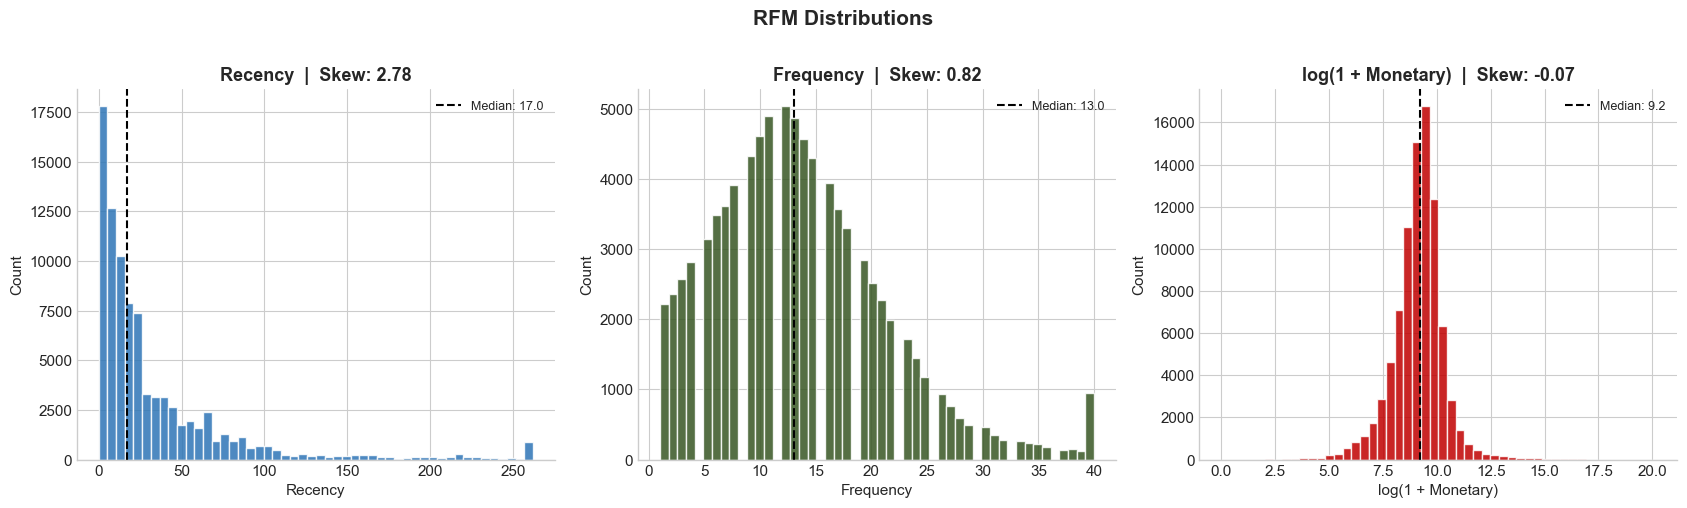

In [11]:
# RFM Distributions
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('RFM Distributions', fontsize=15, fontweight='bold', y=1.01)
for ax, col, color in zip(axes, ['Recency','Frequency','Monetary'], [BLUE, GREEN, RED]):
    data = df_rfm[col].dropna()
    if col == 'Monetary':
        data = np.log1p(data); label = 'log(1 + Monetary)'
    else:
        data = data.clip(upper=data.quantile(0.99)); label = col
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(f'{label}  |  Skew: {stats.skew(data):.2f}', fontweight='bold')
    ax.set_xlabel(label); ax.set_ylabel('Count'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

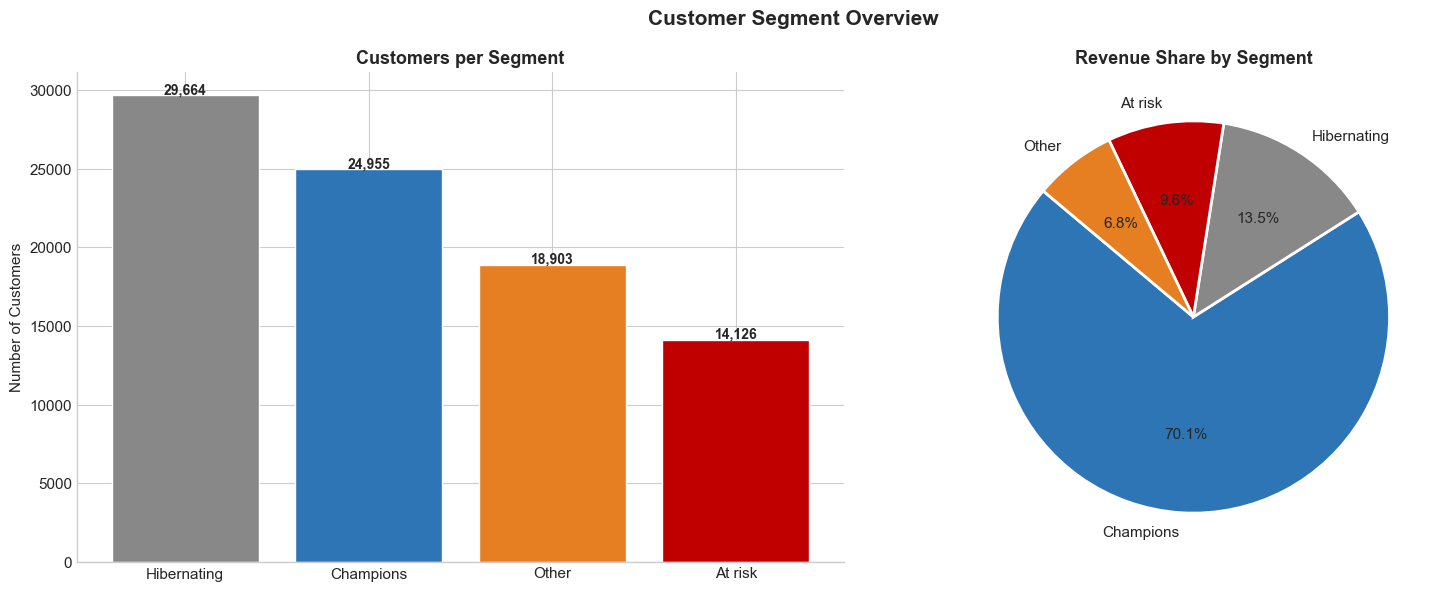

In [12]:
# Segment Overview
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Segment Overview', fontsize=15, fontweight='bold')

seg_order  = seg_counts.sort_values('Count', ascending=False)
bar_colors = [SEG_COLORS.get(s, BLUE) for s in seg_order['Segment']]
bars = axes[0].bar(seg_order['Segment'], seg_order['Count'], color=bar_colors, edgecolor='white')
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for bar, v in zip(bars, seg_order['Count']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{v:,}', ha='center', fontsize=10, fontweight='bold')

seg_mon    = df_rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
pie_colors = [SEG_COLORS.get(s, BLUE) for s in seg_mon.index]
axes[1].pie(seg_mon.values, labels=seg_mon.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Revenue Share by Segment', fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
# Build rfm_cust and rfm_named — required by all subsequent customer charts
rfm_cust = df_rfm.merge(
    df_dim_customer[['CustomerKey','AccountID','AccountName','RegionDescription','SectorDescription']],
    on='CustomerKey', how='left')

# Exclude anonymous / orphan CLIENT_ and UNKNOWN rows from named-customer charts
rfm_named = rfm_cust[
    rfm_cust['AccountName'].notna() &
    ~rfm_cust['AccountName'].str.contains('CLIENT_|UNKNOWN', na=False, regex=True)
].copy()

print(f'rfm_cust  : {len(rfm_cust):,} rows (all customers)')
print(f'rfm_named : {len(rfm_named):,} rows (named customers only, CLIENT_/UNKNOWN excluded)')

rfm_cust  : 87,648 rows (all customers)
rfm_named : 77,306 rows (named customers only, CLIENT_/UNKNOWN excluded)


In [14]:
print("FactSales CustomerKey range:", df_fact_sales['CustomerKey'].min(), "-", df_fact_sales['CustomerKey'].max())
print("DimCustomer CustomerKey range:", df_dim_customer['CustomerKey'].min(), "-", df_dim_customer['CustomerKey'].max())

# Combien de CustomerKeys de FactSales existent dans DimCustomer ?
fact_keys = set(df_fact_sales['CustomerKey'].unique())
dim_keys = set(df_dim_customer['CustomerKey'].unique())
overlap = fact_keys & dim_keys
print(f"\nFactSales unique keys: {len(fact_keys):,}")
print(f"DimCustomer unique keys: {len(dim_keys):,}")
print(f"Keys en commun: {len(overlap):,}")
print(f"Keys orphelines (dans FactSales mais pas DimCustomer): {len(fact_keys - dim_keys):,}")


FactSales CustomerKey range: 1 - 87653
DimCustomer CustomerKey range: 2 - 87653

FactSales unique keys: 87,648
DimCustomer unique keys: 87,652
Keys en commun: 87,647
Keys orphelines (dans FactSales mais pas DimCustomer): 1


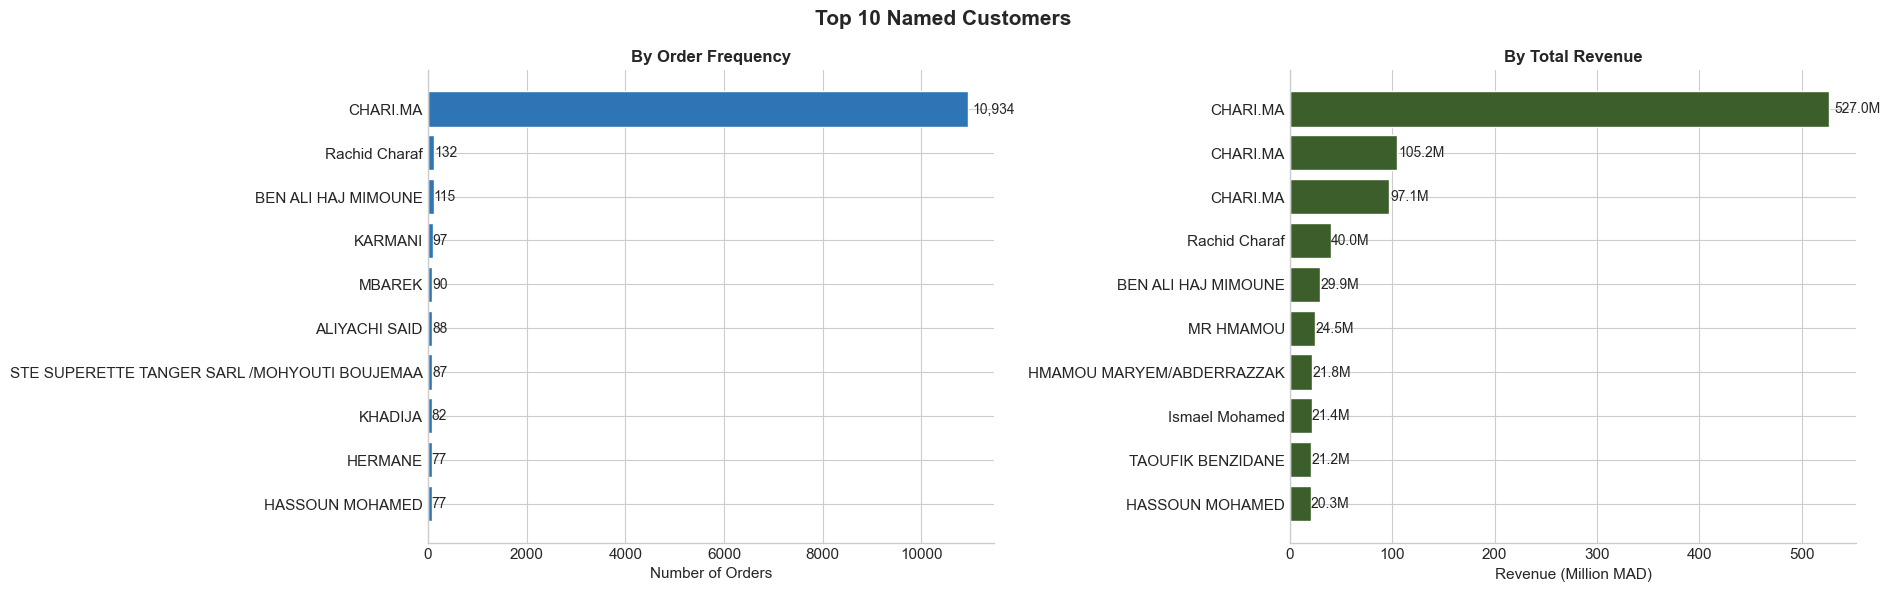

In [32]:
# nlargest pour sélectionner le top 10, sort ascending=True pour que le plus grand soit EN HAUT
top_freq = rfm_named.nlargest(10, 'Frequency').sort_values('Frequency', ascending=True).copy()
top_mon  = rfm_named.nlargest(10, 'Monetary').sort_values('Monetary',   ascending=True).copy()

top_freq['Label'] = top_freq['AccountName']
top_mon['Label']  = top_mon['AccountName']

fig, axes = plt.subplots(1, 2, figsize=(19, 6))
fig.suptitle('Top 10 Named Customers', fontsize=15, fontweight='bold')

y_pos = range(10)

axes[0].barh(y_pos, top_freq['Frequency'].tolist(), color=BLUE, edgecolor='white')
axes[0].set_yticks(y_pos, labels=top_freq['Label'].tolist())
axes[0].set_title('By Order Frequency', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Number of Orders')
for i, v in enumerate(top_freq['Frequency'].tolist()):
    axes[0].text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=10)

axes[1].barh(y_pos, (top_mon['Monetary']/1e6).tolist(), color='#3B5E2B', edgecolor='white')
axes[1].set_yticks(y_pos, labels=top_mon['Label'].tolist())
axes[1].set_title('By Total Revenue', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Revenue (Million MAD)')
for i, v in enumerate((top_mon['Monetary']/1e6).tolist()):
    axes[1].text(v * 1.01, i, f'{v:.1f}M', va='center', fontsize=10)

plt.tight_layout()
plt.show()

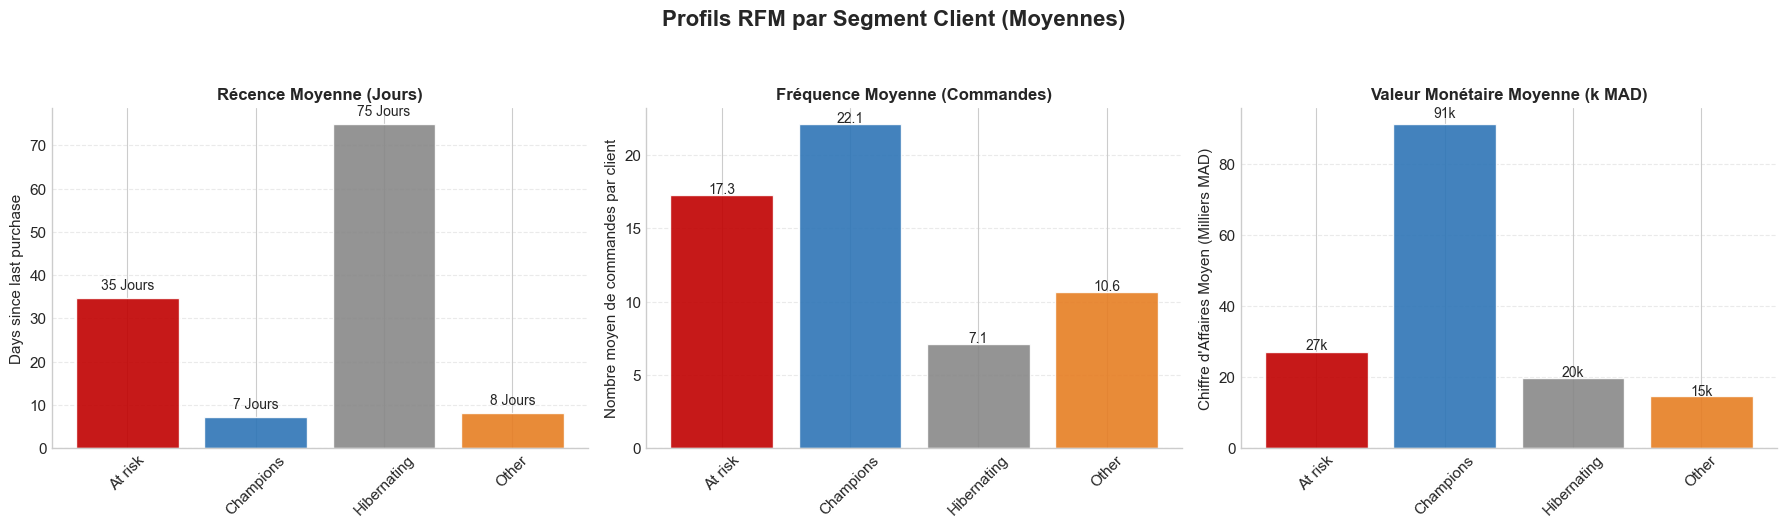

In [16]:
# --- DESIGN 3: Profil Métier des Segments (Le plus clair pour un PFE) ---
# On calcule d'abord la MOYENNE de chaque segment
segment_summary = rfm_named.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerKey': 'count'
}).rename(columns={'CustomerKey': 'Count'})

# On crée une belle figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Profils RFM par Segment Client (Moyennes)', fontsize=16, fontweight='bold', y=1.05)

# --- Variables ---
segs = segment_summary.index
colors = [SEG_COLORS.get(s, BLUE) for s in segs]

# Graphe 1: RECENCE Moyenne (Plus bas c'est mieux)
axes[0].bar(segs, segment_summary['Recency'], color=colors, edgecolor='white', alpha=0.9)
axes[0].set_title('Récence Moyenne (Jours)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Days since last purchase')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
# Ajouter les valeurs sur les barres
for i, v in enumerate(segment_summary['Recency']):
    axes[0].text(i, v + 2, f'{v:.0f} Jours', ha='center', fontsize=10)

# Graphe 2: FRÉQUENCE Moyenne
axes[1].bar(segs, segment_summary['Frequency'], color=colors, edgecolor='white', alpha=0.9)
axes[1].set_title('Fréquence Moyenne (Commandes)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Nombre moyen de commandes par client')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(segment_summary['Frequency']):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=10)

# Graphe 3: MONÉTAIRE Moyen
axes[2].bar(segs, segment_summary['Monetary']/1000, color=colors, edgecolor='white', alpha=0.9)
axes[2].set_title('Valeur Monétaire Moyenne (k MAD)', fontweight='bold', fontsize=12)
axes[2].set_ylabel("Chiffre d'Affaires Moyen (Milliers MAD)")
axes[2].grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(segment_summary['Monetary']/1000):
    axes[2].text(i, v + (v*0.02), f'{v:,.0f}k', ha='center', fontsize=10)

# Nettoyer le design
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


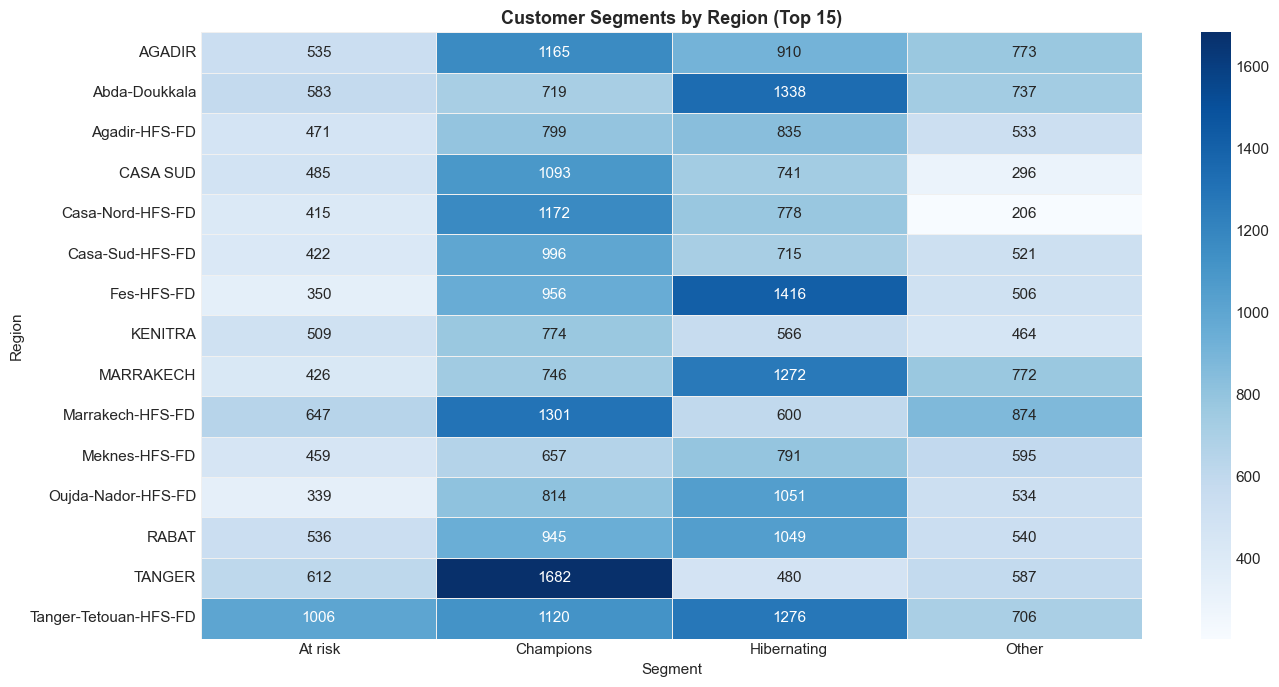

In [17]:
# Heatmap: Region x Segment
rfm_region = rfm_cust.copy()
top_regions = (rfm_region.groupby('RegionDescription')['CustomerKey']
               .count().nlargest(15).index)
rfm_region_top = rfm_region[rfm_region['RegionDescription'].isin(top_regions)]
pivot = rfm_region_top.groupby(['RegionDescription','Segment']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='#f0f0f0', ax=ax)
ax.set_title('Customer Segments by Region (Top 15)', fontweight='bold', fontsize=13)
ax.set_xlabel('Segment'); ax.set_ylabel('Region')
plt.tight_layout(); plt.show()

<a id='6'></a>
## 6. Sales Performance

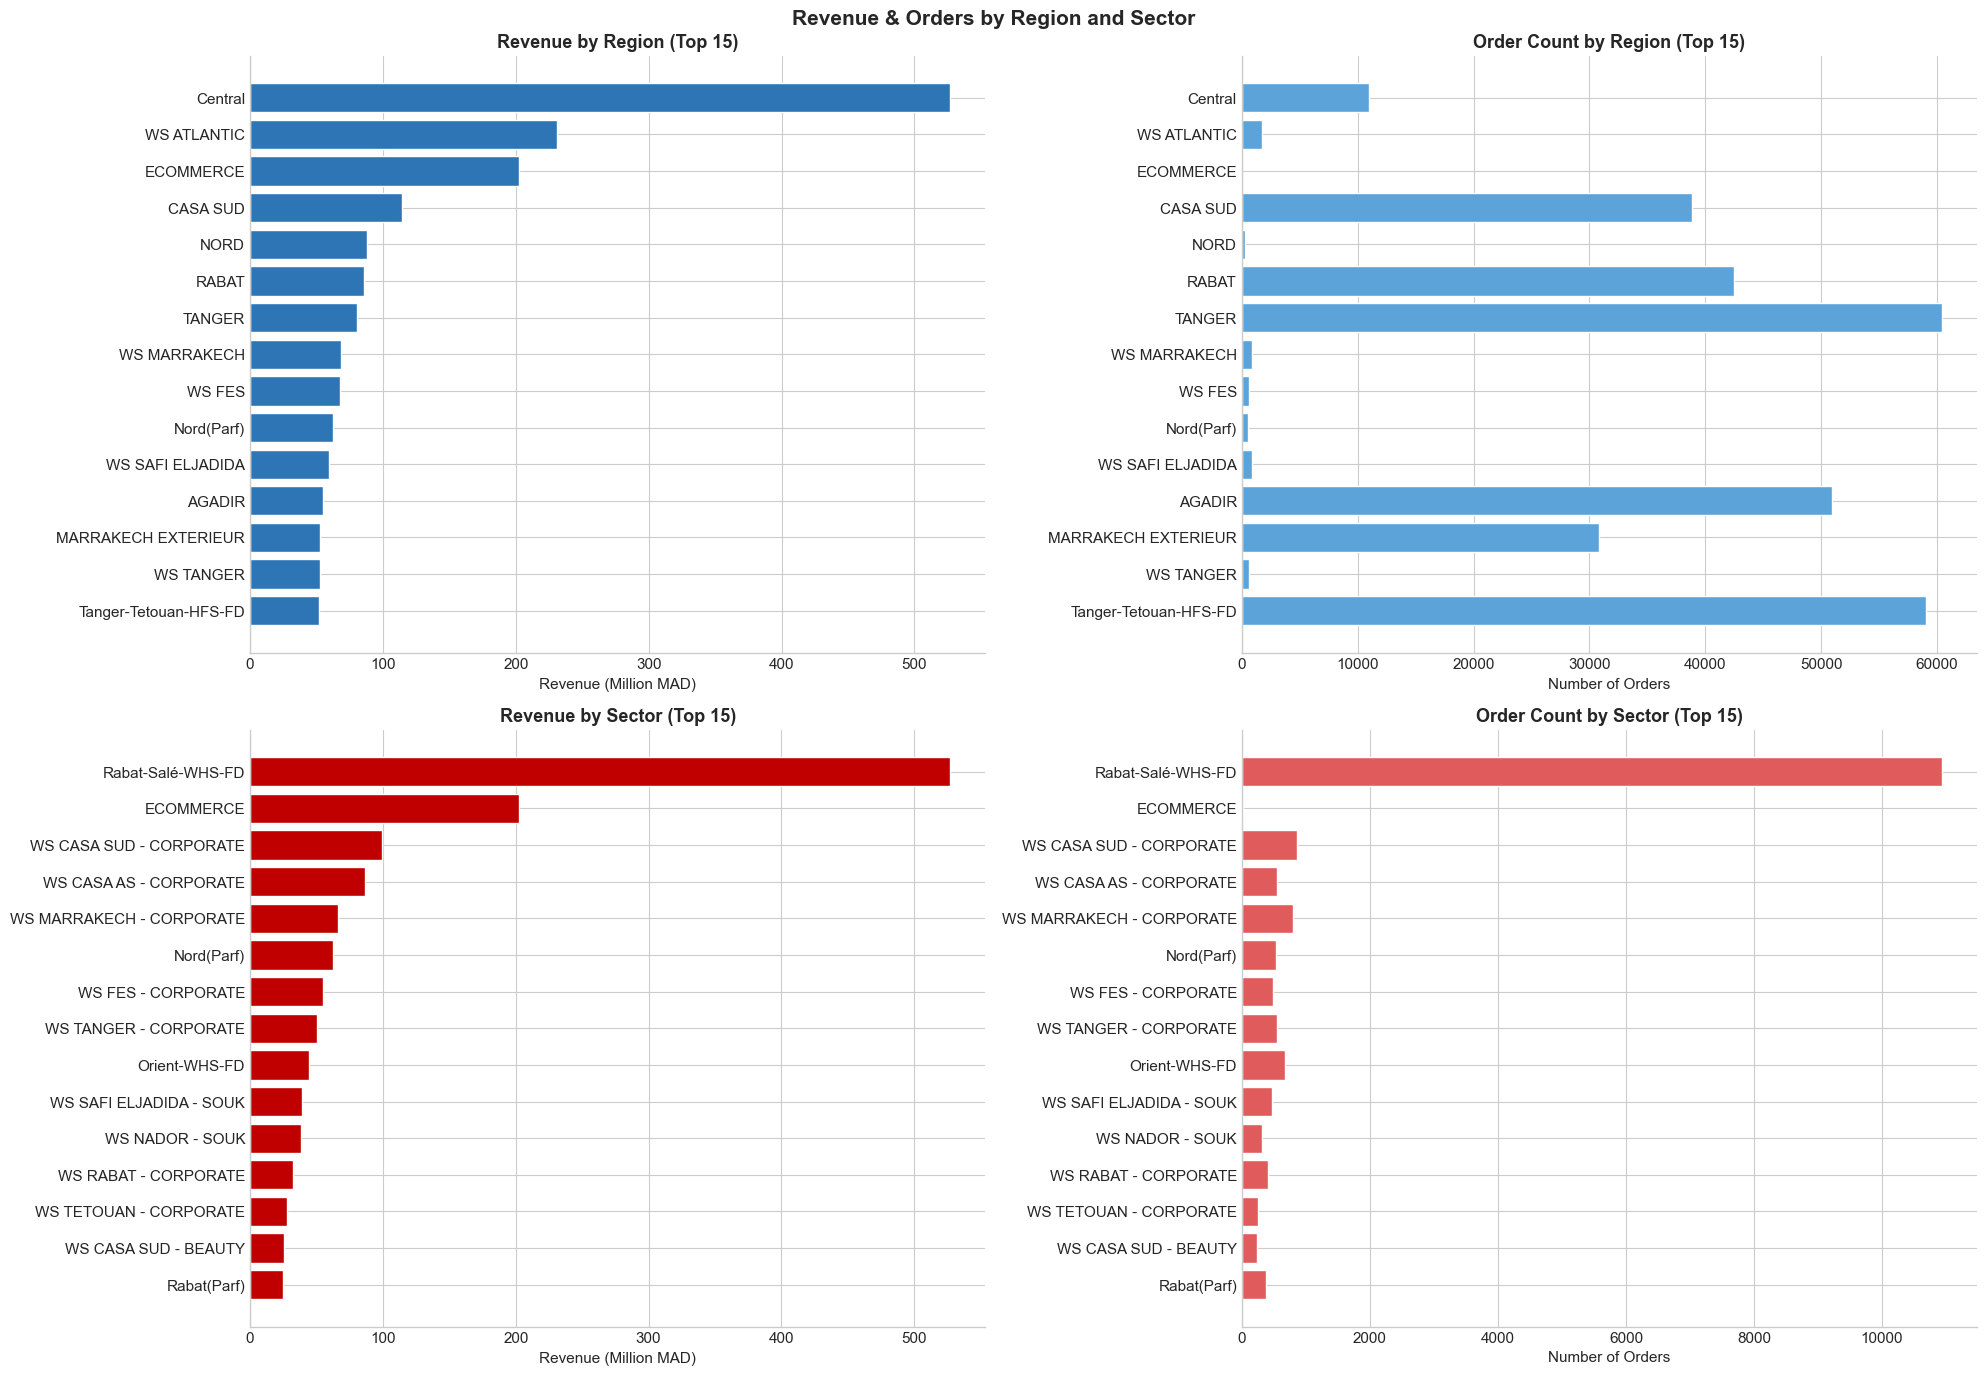

In [18]:
# Revenue & Orders by Region and Sector
sales_by_region = (
    df_fact_sales.merge(df_dim_customer[['CustomerKey','RegionDescription']], on='CustomerKey')
    .groupby('RegionDescription').agg(revenue=('LineTotalAmount','sum'), order_count=('SaleID','nunique'))
    .sort_values('revenue', ascending=False).reset_index())

sales_by_sector = (
    df_fact_sales.merge(df_dim_customer[['CustomerKey','SectorDescription']], on='CustomerKey')
    .groupby('SectorDescription').agg(revenue=('LineTotalAmount','sum'), order_count=('SaleID','nunique'))
    .sort_values('revenue', ascending=False).reset_index())

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Revenue & Orders by Region and Sector', fontsize=15, fontweight='bold')
r15 = sales_by_region.head(15)
s15 = sales_by_sector.head(15)

axes[0,0].barh(r15['RegionDescription'][::-1], r15['revenue'][::-1]/1e6, color=BLUE, edgecolor='white')
axes[0,0].set_title('Revenue by Region (Top 15)', fontweight='bold')
axes[0,0].set_xlabel('Revenue (Million MAD)')

axes[0,1].barh(r15['RegionDescription'][::-1], r15['order_count'][::-1], color=LBLUE, edgecolor='white')
axes[0,1].set_title('Order Count by Region (Top 15)', fontweight='bold')
axes[0,1].set_xlabel('Number of Orders')

axes[1,0].barh(s15['SectorDescription'][::-1], s15['revenue'][::-1]/1e6, color=RED, edgecolor='white')
axes[1,0].set_title('Revenue by Sector (Top 15)', fontweight='bold')
axes[1,0].set_xlabel('Revenue (Million MAD)')

axes[1,1].barh(s15['SectorDescription'][::-1], s15['order_count'][::-1], color='#e05c5c', edgecolor='white')
axes[1,1].set_title('Order Count by Sector (Top 15)', fontweight='bold')
axes[1,1].set_xlabel('Number of Orders')

plt.tight_layout(); plt.show()

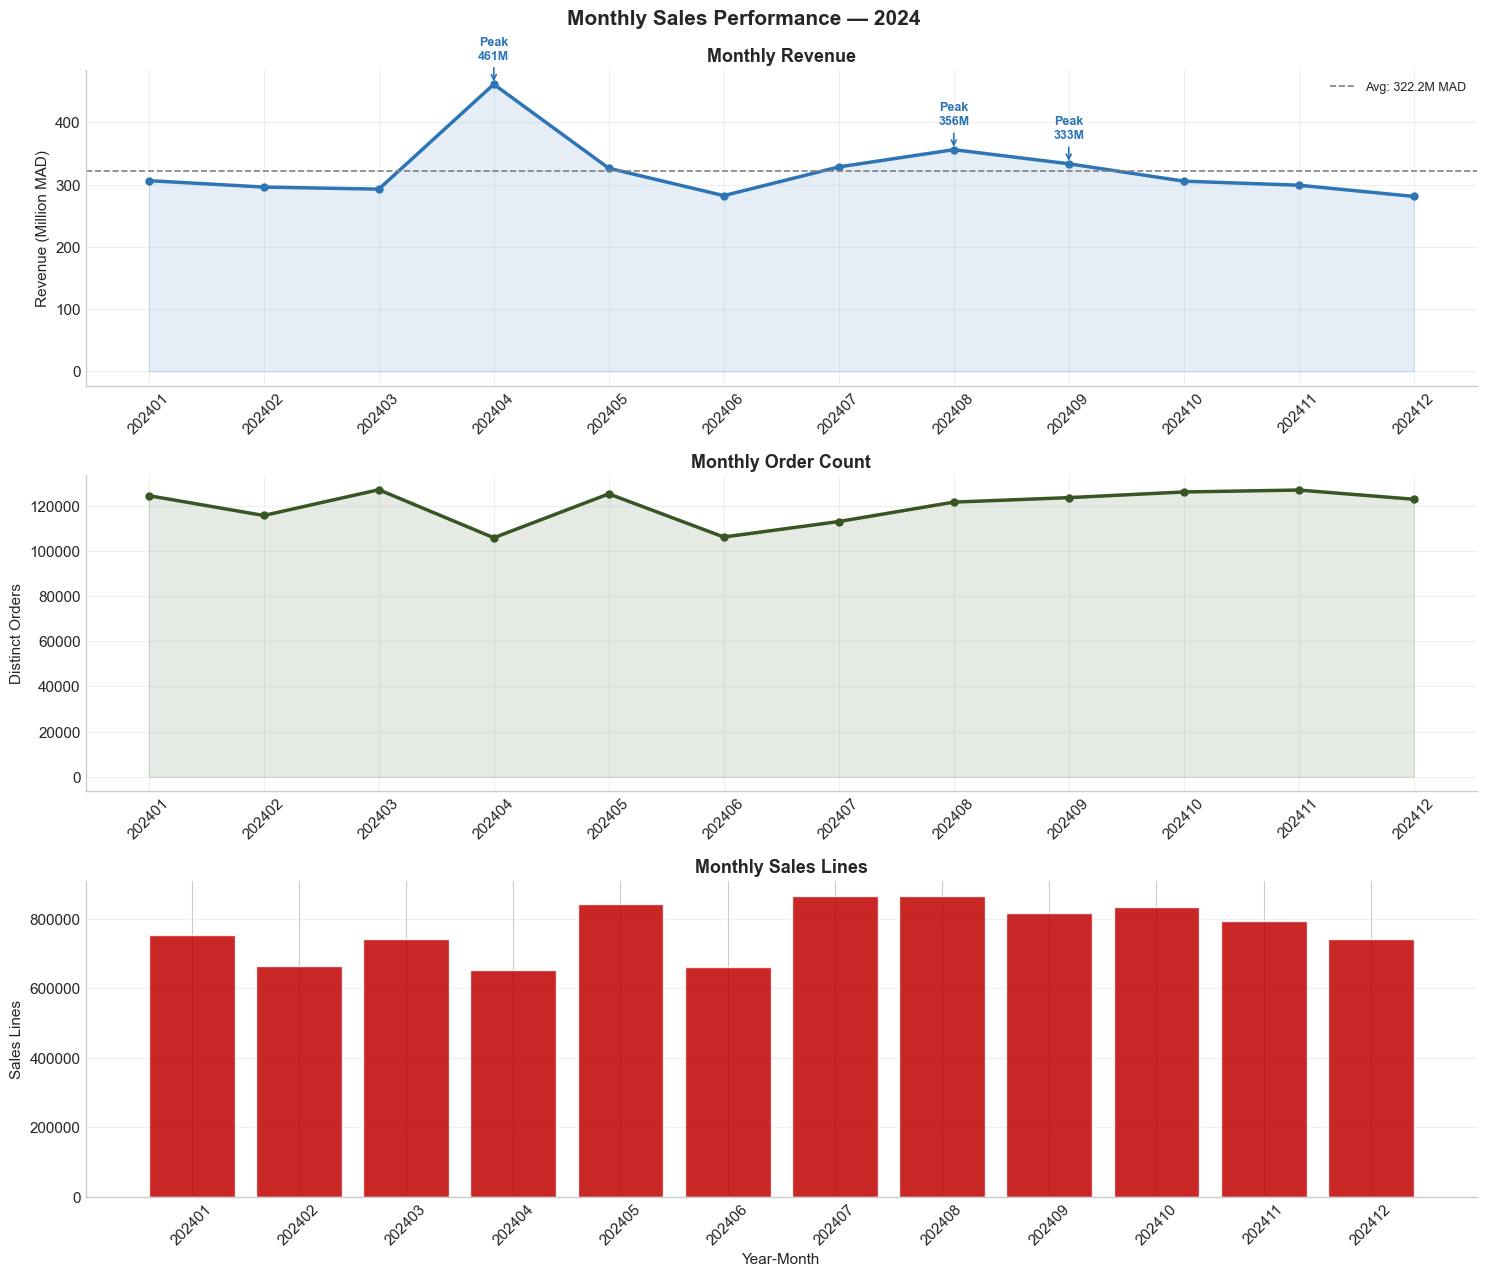

In [19]:
# Monthly Revenue with peak annotations
df_fact_sales['OrderYearMonth'] = (df_fact_sales['OrderDateKey'] // 100).astype(int)
monthly = (
    df_fact_sales.groupby('OrderYearMonth')
    .agg(revenue=('LineTotalAmount','sum'), order_count=('SaleID','nunique'), line_count=('SalesKey','count'))
    .reset_index())
x_labels = monthly['OrderYearMonth'].astype(str)
avg_rev  = monthly['revenue'].mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 13))
fig.suptitle('Monthly Sales Performance — 2024', fontsize=15, fontweight='bold')

axes[0].plot(x_labels, monthly['revenue']/1e6, color=BLUE, linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(x_labels, monthly['revenue']/1e6, alpha=0.12, color=BLUE)
axes[0].axhline(avg_rev/1e6, color='gray', linestyle='--', linewidth=1.2, label=f'Avg: {avg_rev/1e6:.1f}M MAD')
for _, row in monthly.nlargest(3,'revenue').iterrows():
    axes[0].annotate(f"Peak\n{row['revenue']/1e6:.0f}M",
                     xy=(str(int(row['OrderYearMonth'])), row['revenue']/1e6),
                     xytext=(0,18), textcoords='offset points', ha='center',
                     fontsize=9, fontweight='bold', color=BLUE,
                     arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2))
axes[0].set_title('Monthly Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue (Million MAD)')
axes[0].tick_params(axis='x', rotation=45); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(x_labels, monthly['order_count'], color=GREEN, linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(x_labels, monthly['order_count'], alpha=0.12, color=GREEN)
axes[1].set_title('Monthly Order Count', fontweight='bold')
axes[1].set_ylabel('Distinct Orders')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(True, alpha=0.3)

axes[2].bar(x_labels, monthly['line_count'], color=RED, edgecolor='white', alpha=0.85)
axes[2].set_title('Monthly Sales Lines', fontweight='bold')
axes[2].set_ylabel('Sales Lines'); axes[2].set_xlabel('Year-Month')
axes[2].tick_params(axis='x', rotation=45); axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

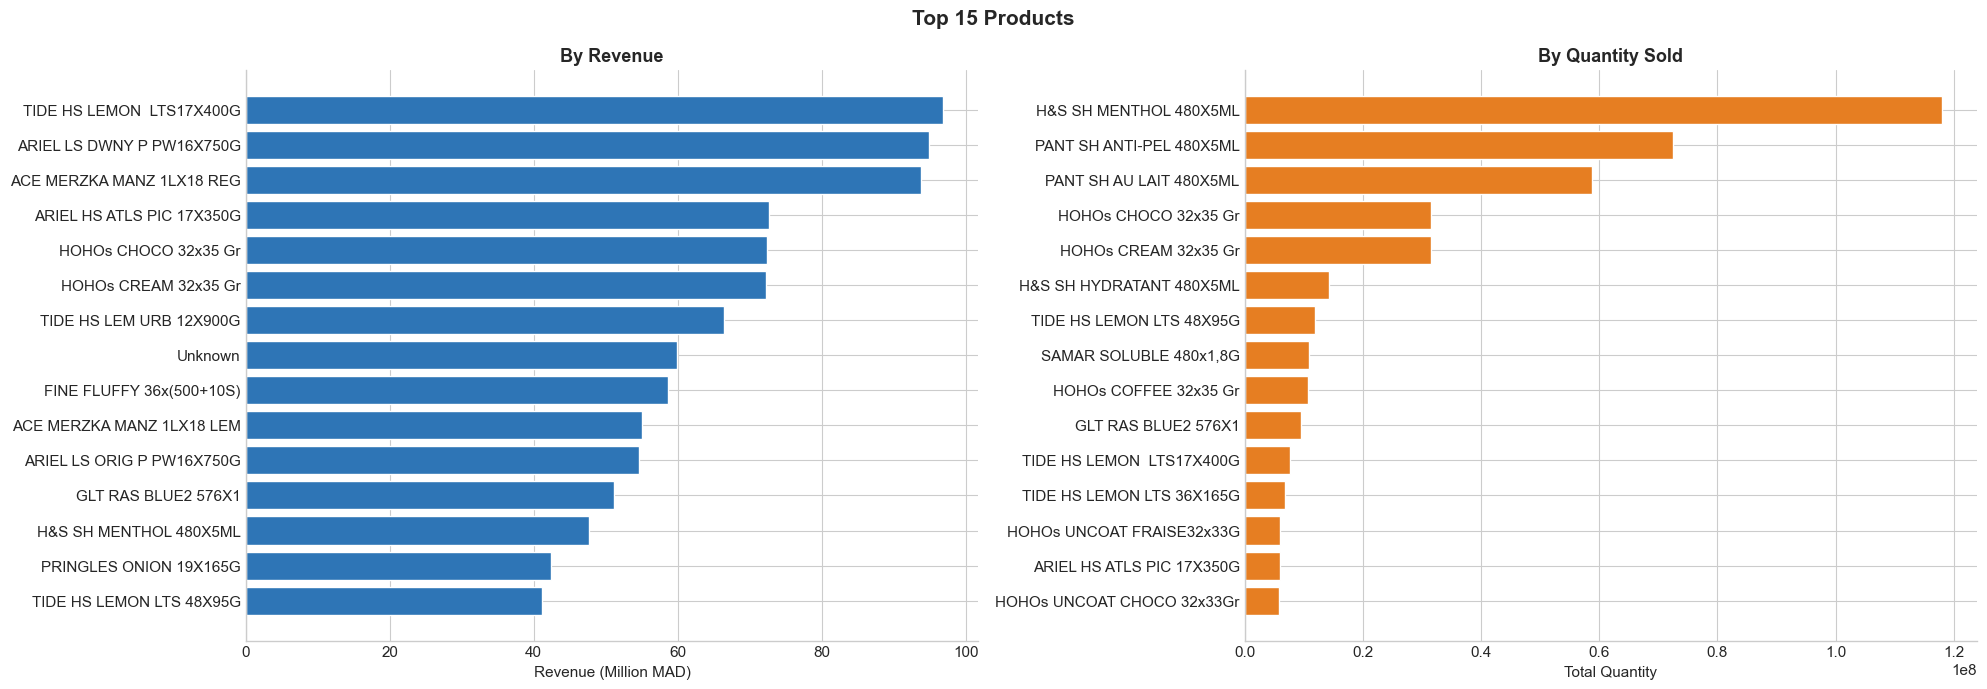

In [20]:
# Top 15 Products
sales_product = df_fact_sales.merge(
    df_dim_product[['ProductKey','ItemID','ProductName','Brand']], on='ProductKey')
def short(name, n=32): return str(name)[:n]+'…' if len(str(name))>n else str(name)

top_rev = (sales_product.groupby(['ItemID','ProductName'])
           .agg(revenue=('LineTotalAmount','sum'), qty=('Quantity','sum'))
           .sort_values('revenue', ascending=False).head(15).reset_index())
top_qty = (sales_product.groupby(['ItemID','ProductName'])
           .agg(revenue=('LineTotalAmount','sum'), qty=('Quantity','sum'))
           .sort_values('qty', ascending=False).head(15).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Top 15 Products', fontsize=15, fontweight='bold')
axes[0].barh([short(n) for n in top_rev['ProductName']][::-1], top_rev['revenue'][::-1]/1e6, color=BLUE, edgecolor='white')
axes[0].set_title('By Revenue', fontweight='bold'); axes[0].set_xlabel('Revenue (Million MAD)')
axes[1].barh([short(n) for n in top_qty['ProductName']][::-1], top_qty['qty'][::-1], color=ORANGE, edgecolor='white')
axes[1].set_title('By Quantity Sold', fontweight='bold'); axes[1].set_xlabel('Total Quantity')
plt.tight_layout(); plt.show()

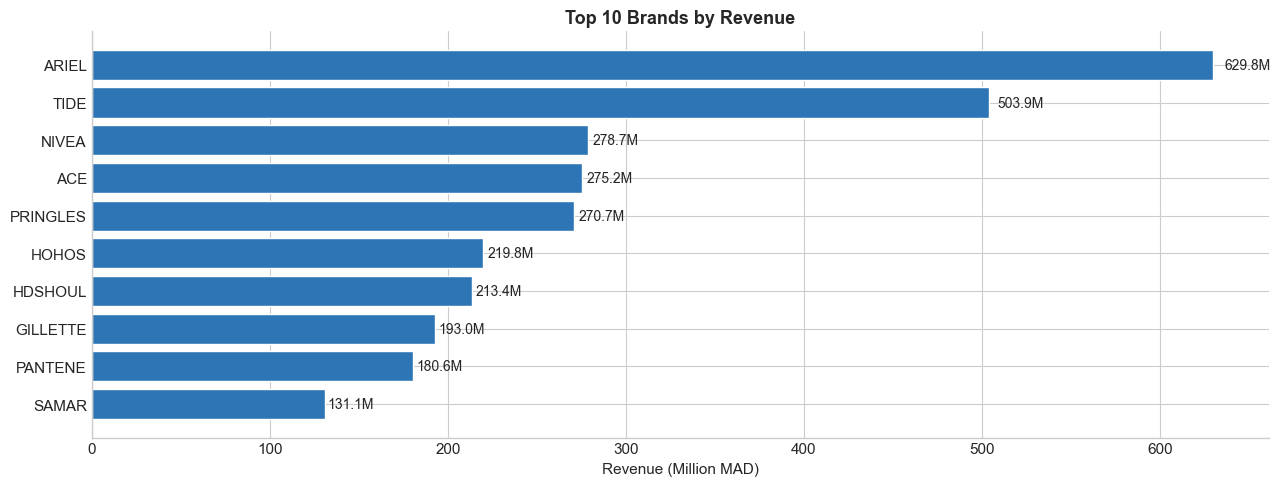

In [21]:
# Top 10 Brands
top_brands = (
    sales_product[~sales_product['Brand'].isin(['Unknown', None, 'nan'])]
    .groupby('Brand')['LineTotalAmount'].sum()
    .sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(top_brands.index[::-1], top_brands.values[::-1]/1e6, color=BLUE, edgecolor='white')
for bar, v in zip(bars, top_brands.values[::-1]/1e6):
    ax.text(v*1.01, bar.get_y()+bar.get_height()/2, f'{v:.1f}M', va='center', fontsize=10)
ax.set_title('Top 10 Brands by Revenue', fontweight='bold')
ax.set_xlabel('Revenue (Million MAD)')
plt.tight_layout(); plt.show()

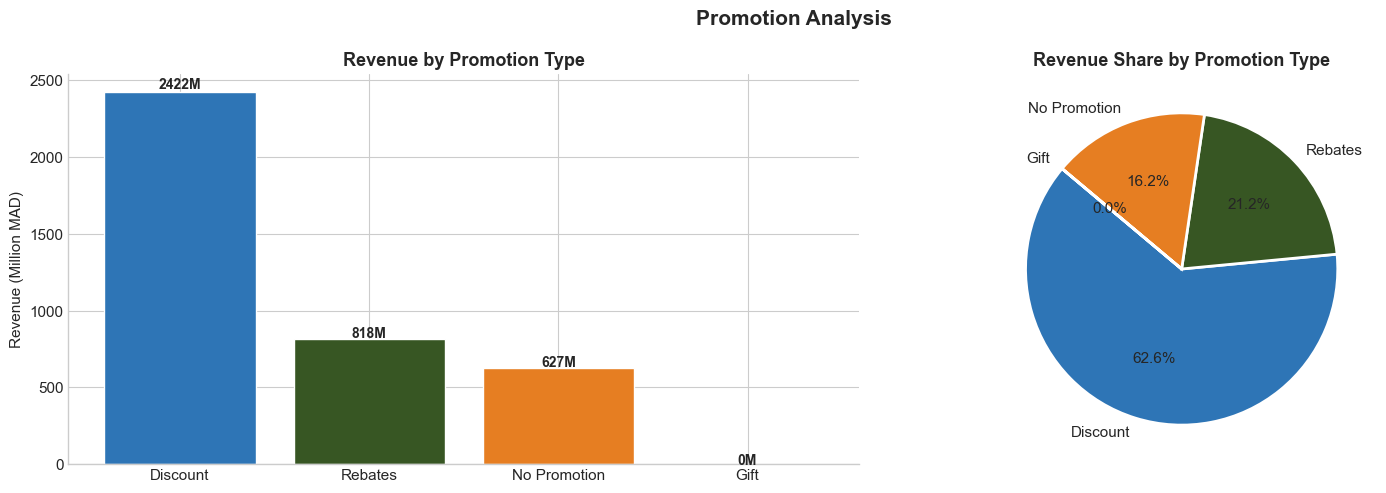

In [22]:
# Promotion Analysis
promo_rev = (
    df_fact_sales.merge(df_dim_promotion[['PromotionKey','PromoType']], on='PromotionKey')
    .groupby('PromoType')['LineTotalAmount'].sum().sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Promotion Analysis', fontsize=15, fontweight='bold')
axes[0].bar(promo_rev.index, promo_rev.values/1e6,
            color=[BLUE, GREEN, ORANGE, RED], edgecolor='white')
axes[0].set_title('Revenue by Promotion Type', fontweight='bold')
axes[0].set_ylabel('Revenue (Million MAD)')
for i, v in enumerate(promo_rev.values/1e6):
    axes[0].text(i, v*1.01, f'{v:.0f}M', ha='center', fontsize=10, fontweight='bold')
axes[1].pie(promo_rev.values, labels=promo_rev.index, autopct='%1.1f%%',
            colors=[BLUE, GREEN, ORANGE, RED], startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Revenue Share by Promotion Type', fontweight='bold')
plt.tight_layout(); plt.show()

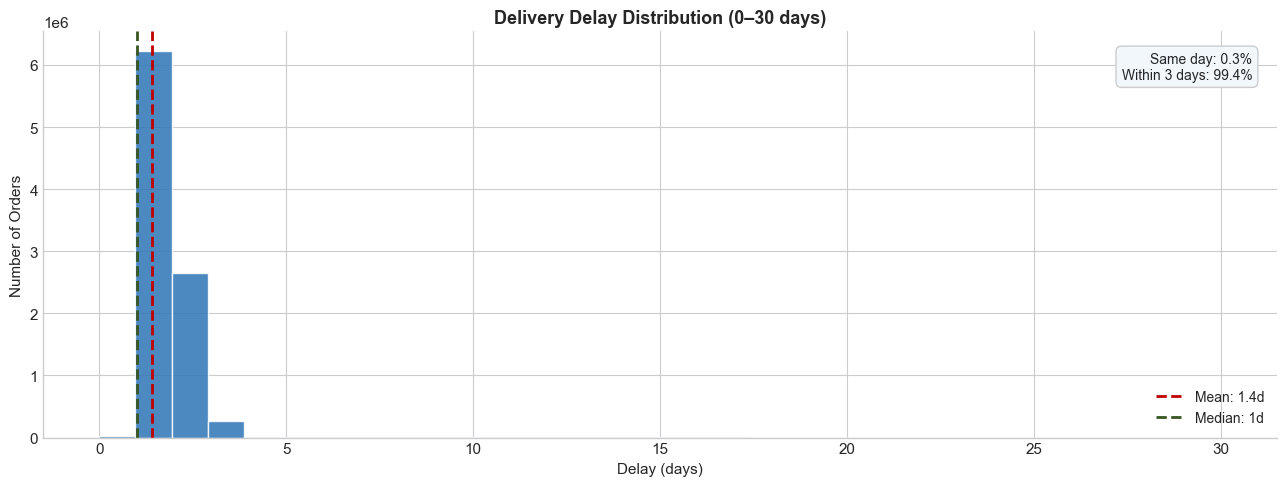

Mean delay: 1.4d | Median: 1d | Same day: 0.3% | Within 3d: 99.4%


In [23]:
# Delivery Delay Distribution
df_delay = df_fact_sales[['OrderDateKey','DeliveryDateKey']].dropna().copy()
df_delay['order_dt']    = pd.to_datetime(df_delay['OrderDateKey'].astype(str),    format='%Y%m%d')
df_delay['delivery_dt'] = pd.to_datetime(df_delay['DeliveryDateKey'].astype(str), format='%Y%m%d')
df_delay['delay_days']  = (df_delay['delivery_dt'] - df_delay['order_dt']).dt.days
df_delay = df_delay[(df_delay['delay_days'] >= 0) & (df_delay['delay_days'] <= 30)]

mean_d   = df_delay['delay_days'].mean()
median_d = df_delay['delay_days'].median()
pct_same = (df_delay['delay_days'] == 0).mean() * 100
pct_3d   = (df_delay['delay_days'] <= 3).mean() * 100

fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(df_delay['delay_days'], bins=31, color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(mean_d,   color=RED,   linestyle='--', linewidth=2, label=f'Mean: {mean_d:.1f}d')
ax.axvline(median_d, color=GREEN, linestyle='--', linewidth=2, label=f'Median: {median_d:.0f}d')
ax.set_title('Delivery Delay Distribution (0–30 days)', fontweight='bold')
ax.set_xlabel('Delay (days)'); ax.set_ylabel('Number of Orders'); ax.legend(fontsize=10)
ax.text(0.98, 0.95, f'Same day: {pct_same:.1f}%\nWithin 3 days: {pct_3d:.1f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor=STRIPE, edgecolor='#ccc'))
plt.tight_layout(); plt.show()
print(f'Mean delay: {mean_d:.1f}d | Median: {median_d:.0f}d | Same day: {pct_same:.1f}% | Within 3d: {pct_3d:.1f}%')

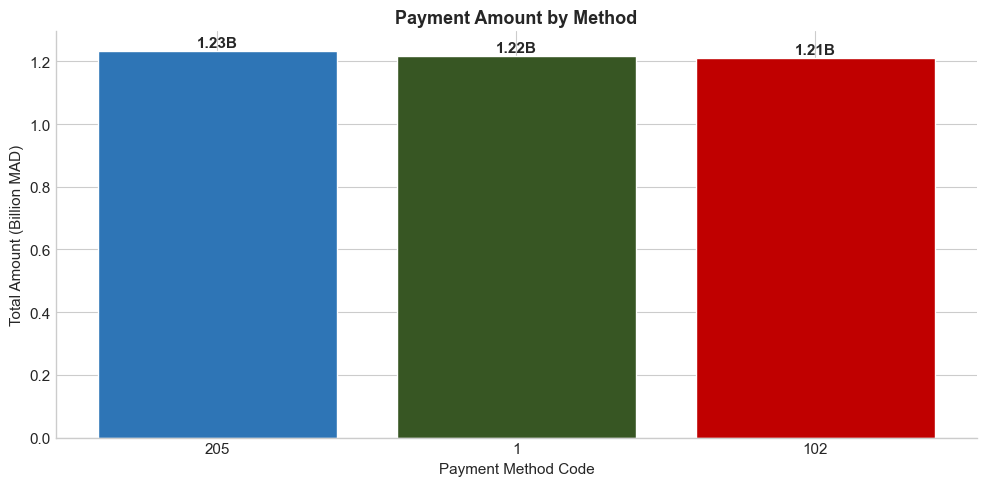

In [24]:
# Payment Method Analysis
pay_rev = (
    df_fact_invoices.merge(df_dim_payment[['PaymentMethodKey','PaymentMethodCode']], on='PaymentMethodKey')
    .groupby('PaymentMethodCode')['PaymentAmount'].sum().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(pay_rev.index.astype(str), pay_rev.values/1e9,
              color=[BLUE, GREEN, RED], edgecolor='white')
for bar, v in zip(bars, pay_rev.values/1e9):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f'{v:.2f}B', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Payment Amount by Method', fontweight='bold')
ax.set_xlabel('Payment Method Code'); ax.set_ylabel('Total Amount (Billion MAD)')
plt.tight_layout(); plt.show()

<a id='7'></a>
## 7. Statistical Deep Dive

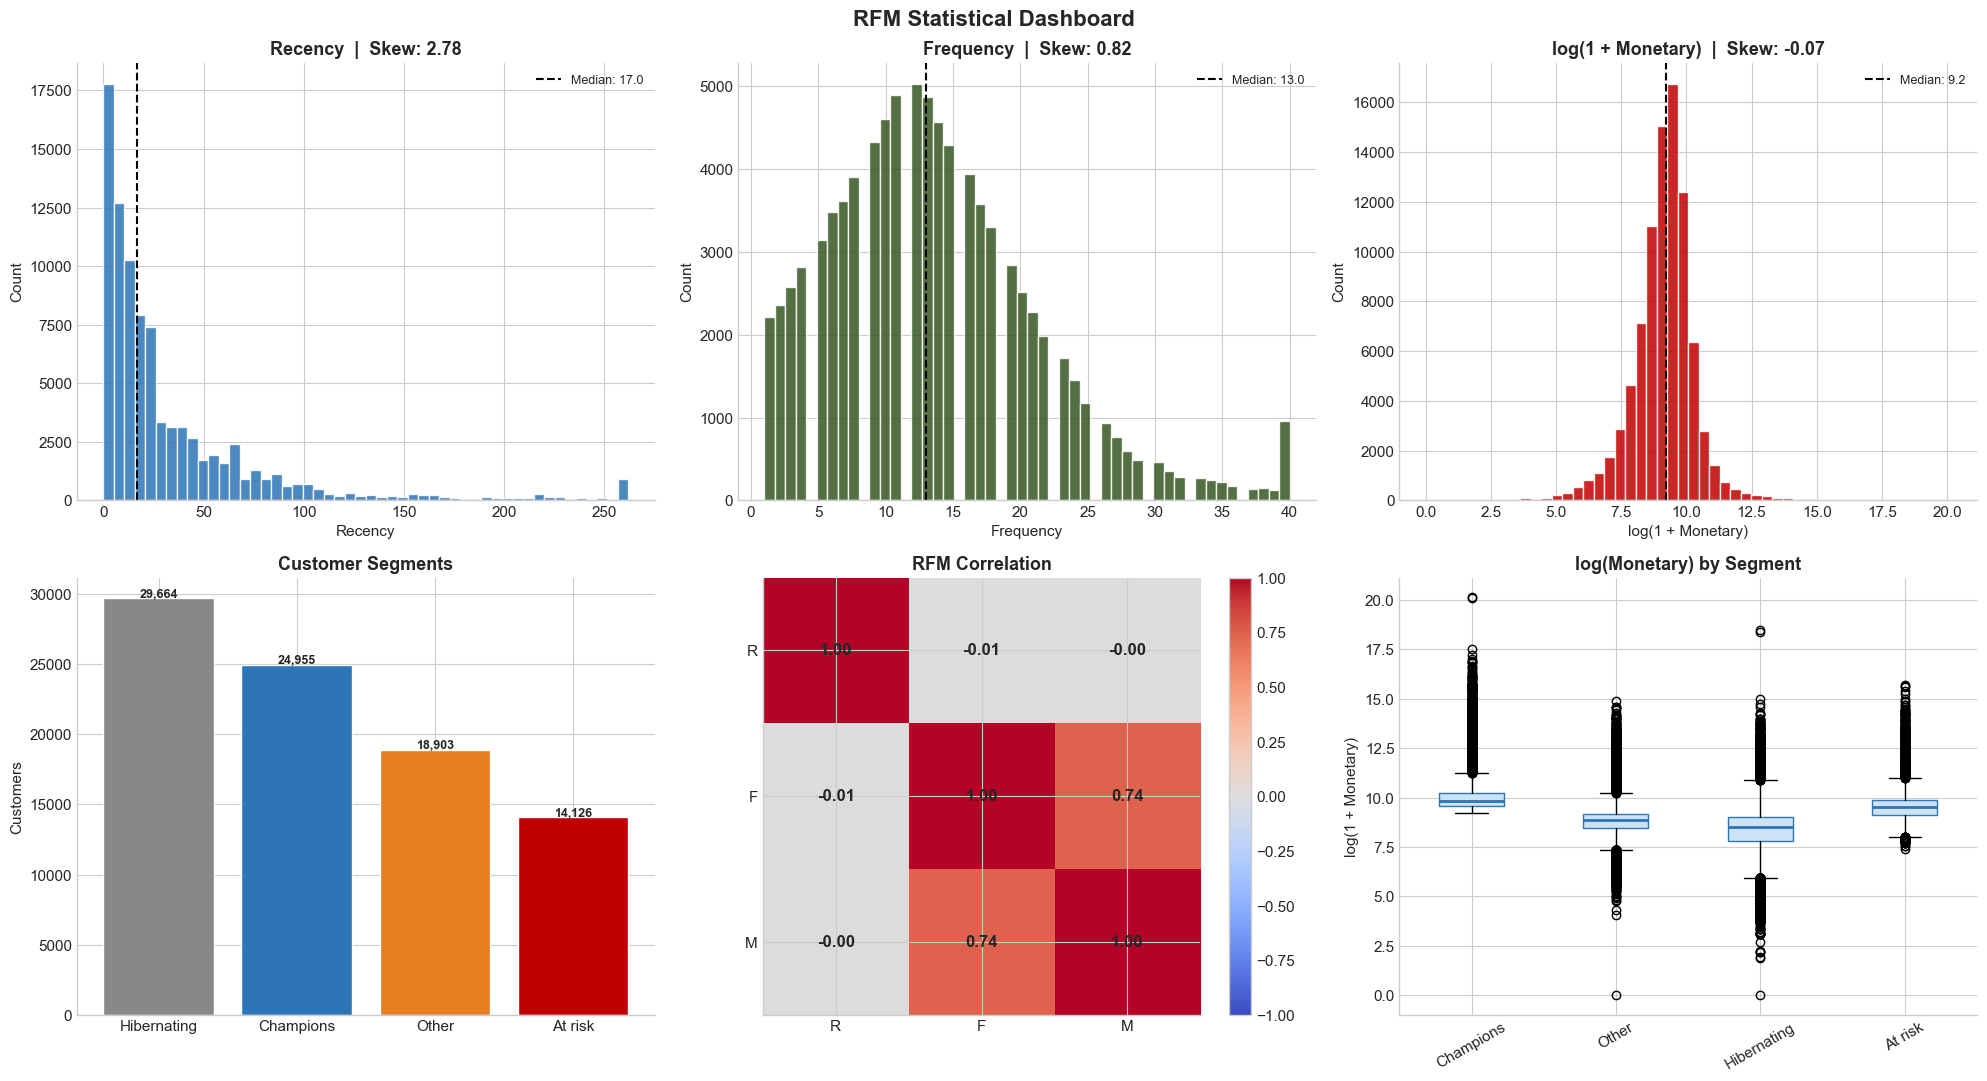

In [25]:
# RFM 2x3 Statistical Dashboard
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('RFM Statistical Dashboard', fontsize=16, fontweight='bold')

for ax, col, color in zip(axes[0], ['Recency','Frequency','Monetary'], [BLUE, GREEN, RED]):
    data = df_rfm[col].dropna()
    if col == 'Monetary':
        data = np.log1p(data); label = 'log(1 + Monetary)'
    else:
        data = data.clip(upper=data.quantile(0.99)); label = col
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(f'{label}  |  Skew: {stats.skew(data):.2f}', fontweight='bold')
    ax.set_xlabel(label); ax.set_ylabel('Count'); ax.legend(fontsize=9)

seg_ord = df_rfm['Segment'].value_counts().sort_values(ascending=False)
bar_c   = [SEG_COLORS.get(s, BLUE) for s in seg_ord.index]
axes[1,0].bar(seg_ord.index, seg_ord.values, color=bar_c, edgecolor='white')
axes[1,0].set_title('Customer Segments', fontweight='bold'); axes[1,0].set_ylabel('Customers')
for i, v in enumerate(seg_ord.values):
    axes[1,0].text(i, v+50, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

corr = df_rfm[['Recency','Frequency','Monetary']].corr()
im   = axes[1,1].imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(3)); axes[1,1].set_yticks(range(3))
axes[1,1].set_xticklabels(['R','F','M']); axes[1,1].set_yticklabels(['R','F','M'])
axes[1,1].set_title('RFM Correlation', fontweight='bold')
for i in range(3):
    for j in range(3):
        axes[1,1].text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[1,1])

df_rfm['Monetary_log'] = np.log1p(df_rfm['Monetary'])
segs     = df_rfm['Segment'].unique()
data_box = [df_rfm[df_rfm['Segment']==s]['Monetary_log'].dropna().values for s in segs]
axes[1,2].boxplot(data_box, labels=segs, patch_artist=True,
                  boxprops=dict(facecolor='#cce3f5', color=BLUE),
                  medianprops=dict(color=BLUE, linewidth=2))
axes[1,2].set_title('log(Monetary) by Segment', fontweight='bold')
axes[1,2].set_ylabel('log(1 + Monetary)'); axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

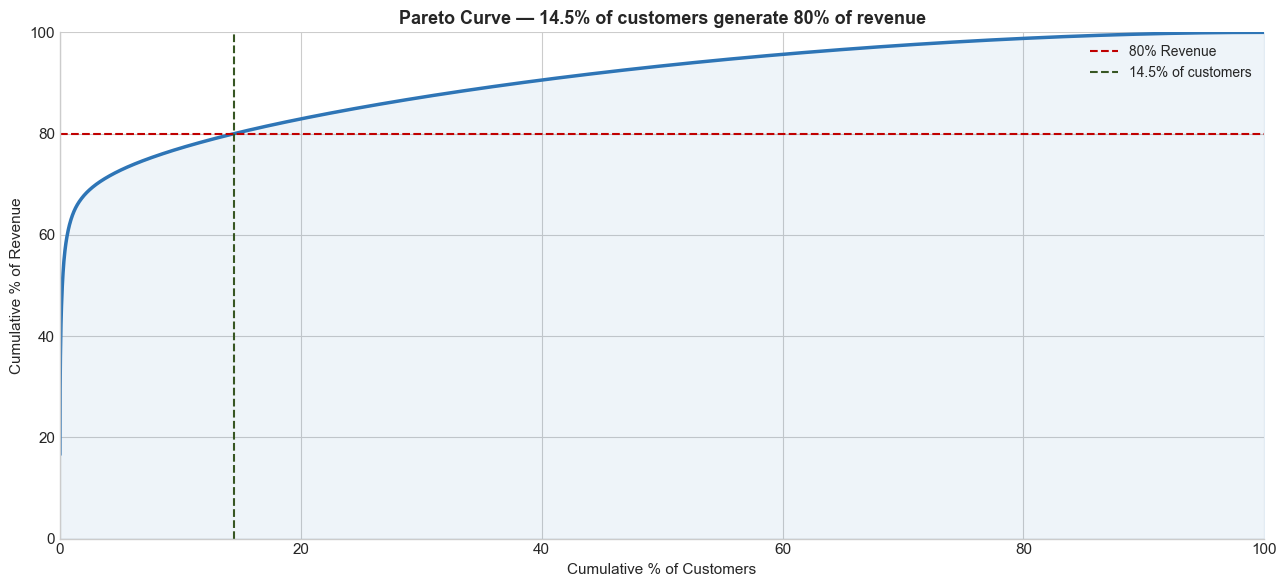

→ 14.5% of customers generate 80% of revenue


In [26]:
# Pareto 80/20 Analysis
rfm_sorted = rfm_named.sort_values('Monetary', ascending=False).reset_index(drop=True)
rfm_sorted['cum_pct_cust'] = (rfm_sorted.index + 1) / len(rfm_sorted) * 100
rfm_sorted['cum_pct_rev']  = rfm_sorted['Monetary'].cumsum() / rfm_sorted['Monetary'].sum() * 100
pct_cust_for_80 = rfm_sorted[rfm_sorted['cum_pct_rev'] >= 80].iloc[0]['cum_pct_cust']

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(rfm_sorted['cum_pct_cust'], rfm_sorted['cum_pct_rev'], color=BLUE, linewidth=2.5)
ax.axhline(80, color=RED,   linestyle='--', linewidth=1.5, label='80% Revenue')
ax.axvline(pct_cust_for_80, color=GREEN, linestyle='--', linewidth=1.5,
           label=f'{pct_cust_for_80:.1f}% of customers')
ax.fill_between(rfm_sorted['cum_pct_cust'], rfm_sorted['cum_pct_rev'], alpha=0.08, color=BLUE)
ax.set_title(f'Pareto Curve — {pct_cust_for_80:.1f}% of customers generate 80% of revenue',
             fontweight='bold')
ax.set_xlabel('Cumulative % of Customers'); ax.set_ylabel('Cumulative % of Revenue')
ax.legend(fontsize=10); ax.set_xlim(0,100); ax.set_ylim(0,100)
plt.tight_layout(); plt.show()
print(f'→ {pct_cust_for_80:.1f}% of customers generate 80% of revenue')

<a id='8'></a>
## 8. Save & Next Steps

In [27]:
# Save RFM for Phase 3
out_dir = PROJECT_ROOT / 'Data' / 'rfm'
out_dir.mkdir(parents=True, exist_ok=True)
df_rfm.to_csv(out_dir / 'rfm_customers.csv', index=False)
print(f'✅ RFM saved → {out_dir / "rfm_customers.csv"}')
print(f'   Shape: {df_rfm.shape} | Columns: {list(df_rfm.columns)}')

✅ RFM saved → c:\Users\21261\Desktop\dislog-pfe\Data\rfm\rfm_customers.csv
   Shape: (87648, 10) | Columns: ['CustomerKey', 'Recency', 'Frequency', 'Monetary', 'R_quartile', 'F_quartile', 'M_quartile', 'RFM_score', 'Segment', 'Monetary_log']


---
## Summary & Key Findings

| Metric | Value |
|---|---|
| Total customers (DimCustomer) | 104,794 |
| Total sales lines (FactSales) | 9,229,070 |
| Total invoices (FactInvoices) | 1,437,421 |
| Date range | 2024-01-01 → 2024-12-31 |
| RFM customers computed | 87,648+ |
| Champions segment | ~25K customers |
| Hibernating segment | ~30K customers |
| F↔M correlation | 0.74 (strong) |

**→ Phase 3**: K-Means clustering, XGBoost churn prediction, CLV modeling.